<a href="https://colab.research.google.com/github/RananJ/ML/blob/main/ML_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [20]:
file_path=r"/content/breast_cancer.csv"
df=pd.read_csv(file_path)
df=df.drop(columns=[col for col in df.columns if "id" in col.lower() or "unnamed" in col.lower()],errors="ignore")
if "diagnosis" in df.columns:
  df["diagnosis"]=df["diagnosis"].map({"M": 0, "B":1})
if "diagnosis" in df.columns:
  df.rename(columns={"diagnosis":"target"},inplace=True)


In [21]:
x=df.drop("target",axis=1)
y=df["target"]

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [25]:
model=LogisticRegression(max_iter=5000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=5000)

In [26]:
y_pred=model.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Classification Report:",classification_report(y_test,y_pred))


Accuracy 0.9736842105263158
Classification Report:               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



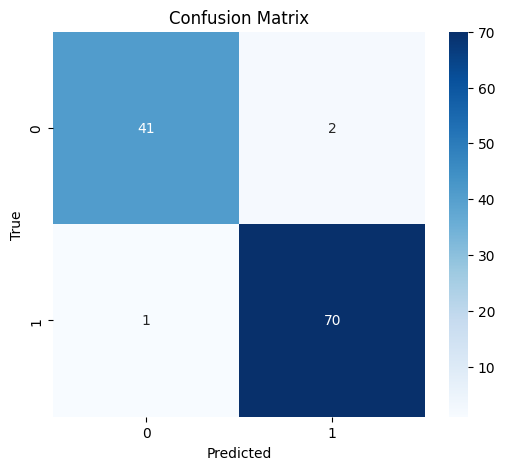

In [27]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()